In [2]:
import numpy as np
import pandas as pd
#mport h5py
from astropy.io import fits
import warnings

%matplotlib inline
import glob, os, sys, timeit
import matplotlib
import numpy as np

sys.path.append('../')
from pyqsofit.PyQSOFit import QSOFit
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt
import warnings

from astropy.coordinates import SkyCoord

from speclite import filters

warnings.filterwarnings("ignore")

QSOFit.set_mpl_style()

In [3]:
import h5py
from tqdm import tqdm

def read_quasars_from_hdf5(file_path):
    quasar_list = []
    with h5py.File(file_path, "r") as hdf:
        for group_name in tqdm(hdf.keys(), desc="Reading quasars"):
            group = hdf[group_name]
            quasar = {"object_id": group_name}
            for key, value in group.attrs.items():
                quasar[key] = value
            for sub_group_name in group.keys():
                sub_group = group[sub_group_name]
                quasar[sub_group_name] = {sub_key: sub_group[sub_key][...] for sub_key in sub_group.keys()}
            quasar_list.append(quasar)
    return quasar_list


objs = read_quasars_from_hdf5("data/july2_hd_objects_means.h5")

Reading quasars: 100%|██████████| 1402/1402 [00:00<00:00, 10166.73it/s]


In [4]:
def get_fiber_mag(coord: SkyCoord, radius_arcsec=2, bands=['u', 'g', 'r', 'i', 'z']):
    """
    Get inverse variance weighted mean fiber magnitudes for all SDSS bands.

    Parameters:
    - coord: SkyCoord object
    - radius_arcsec: search radius in arcseconds

    Returns:
    - dict with keys 'u','g','r','i','z' and weighted mean magnitudes as values,
      or None if no data for that band.
    """
    radius = radius_arcsec * u.arcsec

    # Build list of fields to query
    fields = []
    for b in bands:
        fields.append(f'fiberMag_{b}')
        fields.append(f'fiberMagErr_{b}')

    data = SDSS.query_region(coord, radius=radius, photoobj_fields=fields)
    if data is None or len(data) == 0:
        return {b: None for b in bands}

    weighted_means = {}
    for b in bands:
        mags = data[f'fiberMag_{b}']
        errs = data[f'fiberMagErr_{b}']

        mask = (~np.isnan(mags)) & (~np.isnan(errs)) & (errs > 0)
        mags = mags[mask]
        errs = errs[mask]

        if len(mags) == 0:
            weighted_means[b] = None
            continue

        weights = 1 / (errs ** 2)
        weighted_mean = np.sum(weights * mags) / np.sum(weights)
        weighted_means[b] = weighted_mean

    return weighted_means

In [5]:
pd.read_csv('data/agn_sdssname_m2500.csv')['object_id']

0       1385049
1       1387512
2       1387735
3       1387813
4       1387875
         ...   
1398    1466184
1399    1466233
1400    1466243
1401    1466282
1402    1466289
Name: object_id, Length: 1403, dtype: int64

In [6]:
from astropy import units as u
from astropy.table import Table

with fits.open('data/dr16q_prop_May01_2024.fits') as hdul:
    data_cat = hdul[1].data
    #data_cat = data_cat[data_cat['Z_SYS'] <1]

    coords_sdss = SkyCoord(
        ra=data_cat['RA'],
        dec=data_cat['DEC'],
        unit=(u.deg, u.deg),
        frame='icrs'
    )

    agn_df = pd.read_csv('data/agn_sdssname_m2500.csv')

    # ...existing code...
    # Ensure all object_ids are strings and stripped
    agn_df['object_id'] = agn_df['object_id'].astype(str).str.strip()
    obj_mean_corr_map = {str(obj['object_id']).strip(): obj['mean_corrected'] for obj in objs}

    # Create new columns for each band
    bands = ['g', 'r', 'i', 'z', 'u']
    for i, band in enumerate(bands):
        agn_df[f'mean_corrected_{band}'] = agn_df['object_id'].map(
            lambda oid: obj_mean_corr_map.get(oid, [np.nan]*5)[i]
        )
    # ...existing code...

    coords_agn = SkyCoord(
        ra=agn_df['ra'],
        dec=agn_df['dec'],
        unit=(u.deg, u.deg),
        frame='icrs'
    )

    # Match using search_around_sky to find all pairs within a certain separation
    max_sep = 2.0 * u.arcsec  # maximum separation for matching

    idx_sdss, idx_agn, sep2d, _ = coords_agn.search_around_sky(coords_sdss, max_sep)

    # Store matches in a DataFrame for further analysis
    matches_df = pd.DataFrame({
        'agn_idx': idx_agn,
        'sdss_idx': idx_sdss,
        'sep_arcsec': sep2d.arcsec
    })

    # Only keep data_cat rows where there is a match
    matched_sdss_indices = np.unique(idx_sdss)
    data_cat = data_cat[matched_sdss_indices]
    # Add apparent_mag_2500 from agn_df into data_cat by matching indices
    # Assume agn_df has a column 'apparent_mag_2500' and matches to data_cat via matched_sdss_indices

    # Only keep rows in agn_df that correspond to matched_sdss_indices
    agn_df_matched = agn_df.iloc[idx_agn].reset_index(drop=True)

    # Add apparent_mag_2500 from agn_df_matched to data_cat as a new column
    # Assumes agn_df_matched['apparent_mag_2500'] exists and matches the order of data_cat after filtering


    # Convert data_cat to Table if not already
    if not isinstance(data_cat, Table):
        data_cat = Table(data_cat)

    data_cat['apparent_mag_2500'] = agn_df_matched['apparent_mag_2500'].values

    # Add the mean_corrected magnitudes for each band to data_cat
    # The order of agn_df_matched matches data_cat after filtering

    for i, band in enumerate(bands):
        data_cat[f'mean_corrected_{band}'] = agn_df_matched[f'mean_corrected_{band}'].values

In [7]:
path_ex = '.' #os.path.join(pyqsofit.__path__[0], '..', 'example')

# create a header
hdr0 = fits.Header()
hdr0['Author'] = 'Hengxiao Guo'
primary_hdu = fits.PrimaryHDU(header=hdr0)

line_priors = np.rec.array([
    (6564.61, 'Ha', 6400, 6800, 'Ha_br', 2, 0.0, 0.0, 1e10, 5e-3, 0.004, 0.05, 0.015, 0, 0, 0, 0.05, 1),
    (6564.61, 'Ha', 6400, 6800, 'Ha_na', 1, 0.0, 0.0, 1e10, 1e-3, 5e-4, 0.00169, 0.01, 1, 1, 0, 0.002, 1),
    (6549.85, 'Ha', 6400, 6800, 'NII6549', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.00169, 5e-3, 1, 1, 1, 0.001, 1),
    (6585.28, 'Ha', 6400, 6800, 'NII6585', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.00169, 5e-3, 1, 1, 1, 0.003, 1),
    (6718.29, 'Ha', 6400, 6800, 'SII6718', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.00169, 5e-3, 1, 1, 2, 0.001, 1),
    (6732.67, 'Ha', 6400, 6800, 'SII6732', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.00169, 5e-3, 1, 1, 2, 0.001, 1),

    (4862.68, 'Hb', 4640, 5100, 'Hb_br', 2, 0.0, 0.0, 1e10, 5e-3, 0.004, 0.05, 0.01, 0, 0, 0, 0.01, 1),
    (4862.68, 'Hb', 4640, 5100, 'Hb_na', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.00169, 0.01, 1, 1, 0, 0.002, 1),
    (4960.30, 'Hb', 4640, 5100, 'OIII4959c', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.00169, 0.01, 1, 1, 0, 0.002, 1),
    (5008.24, 'Hb', 4640, 5100, 'OIII5007c', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.00169, 0.01, 1, 1, 0, 0.004, 1),
    (4960.30, 'Hb', 4640, 5100, 'OIII4959w',   1, 0.0, 0.0, 1e10, 3e-3, 2.3e-4, 0.004,  0.01,  2, 2, 0, 0.001, 1),
    (5008.24, 'Hb', 4640, 5100, 'OIII5007w',   1, 0.0, 0.0, 1e10, 3e-3, 2.3e-4, 0.004,  0.01,  2, 2, 0, 0.002, 1),
    #(4687.02, 'Hb', 4640, 5100, 'HeII4687_br', 1, 0.0, 0.0, 1e10, 5e-3, 0.004,  0.05,   0.005, 0, 0, 0, 0.001, 1),
    #(4687.02, 'Hb', 4640, 5100, 'HeII4687_na', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.00169, 0.005, 1, 1, 0, 0.001, 1),
    
    (4341.68, 'Hg', 4200, 4400, 'Hg_br', 1, 0.0, 0.0, 1e10, 5e-3, 0.004, 0.05, 0.01, 0, 0, 0, 0.01, 1),
    (4341.68, 'Hg', 4200, 4400, 'Hg_na', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.00169, 0.01, 1, 1, 0, 0.002, 1),
    (4102.89, 'Hd', 4000, 4150, 'Hd_br', 1, 0.0, 0.0, 1e10, 5e-3, 0.004, 0.05, 0.01, 0, 0, 0, 0.01, 1),
    (4102.89, 'Hd', 4000, 4150, 'Hd_na', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.00169, 0.01, 1, 1, 0, 0.002, 1),

    #(3934.78, 'CaII', 3900, 3960, 'CaII3934' , 2, 0.0, 0.0, 1e10, 1e-3, 3.333e-4, 0.00169, 0.01, 99, 0, 0, -0.001, 1),

    #(3728.48, 'OII', 3650, 3800, 'OII3728', 1, 0.0, 0.0, 1e10, 1e-3, 3.333e-4, 0.00169, 0.01, 1, 1, 0, 0.001, 1),

    #(3426.84, 'NeV', 3380, 3480, 'NeV3426',    1, 0.0, 0.0, 1e10, 1e-3, 3.333e-4, 0.00169, 0.01, 0, 0, 0, 0.001, 1),
    #(3426.84, 'NeV', 3380, 3480, 'NeV3426_br', 1, 0.0, 0.0, 1e10, 5e-3, 0.0025,   0.02,   0.01, 0, 0, 0, 0.001, 1),

    (2798.75, 'MgII', 2700, 2900, 'MgII_br', 2, 0.0, 0.0, 1e10, 5e-3, 0.004, 0.05, 0.015, 0, 0, 0, 0.05, 1),
    (2798.75, 'MgII', 2700, 2900, 'MgII_na', 1, 0.0, 0.0, 1e10, 1e-3, 5e-4, 0.00169, 0.01, 1, 1, 0, 0.002, 1),

    (1908.73, 'CIII', 1700, 1970, 'CIII_br', 2, 0.0, 0.0, 1e10, 5e-3, 0.004, 0.05, 0.015, 99, 0, 0, 0.01, 1),
    #(1908.73, 'CIII', 1700, 1970, 'CIII_na',   1, 0.0, 0.0, 1e10, 1e-3, 5e-4,  0.00169, 0.01,  1, 1, 0, 0.002, 1),
    #(1892.03, 'CIII', 1700, 1970, 'SiIII1892', 1, 0.0, 0.0, 1e10, 2e-3, 0.001, 0.015,  0.003, 1, 1, 0, 0.005, 1),
    #(1857.40, 'CIII', 1700, 1970, 'AlIII1857', 1, 0.0, 0.0, 1e10, 2e-3, 0.001, 0.015,  0.003, 1, 1, 0, 0.005, 1),
    #(1816.98, 'CIII', 1700, 1970, 'SiII1816',  1, 0.0, 0.0, 1e10, 2e-3, 0.001, 0.015,  0.01,  1, 1, 0, 0.0002, 1),
    #(1786.7,  'CIII', 1700, 1970, 'FeII1787',  1, 0.0, 0.0, 1e10, 2e-3, 0.001, 0.015,  0.01,  1, 1, 0, 0.0002, 1),
    #(1750.26, 'CIII', 1700, 1970, 'NIII1750',  1, 0.0, 0.0, 1e10, 2e-3, 0.001, 0.015,  0.01,  1, 1, 0, 0.001, 1),
    #(1718.55, 'CIII', 1700, 1900, 'NIV1718',   1, 0.0, 0.0, 1e10, 2e-3, 0.001, 0.015,  0.01,  1, 1, 0, 0.001, 1),

    (1549.06, 'CIV', 1500, 1700, 'CIV_br', 2, 0.0, 0.0, 1e10, 5e-3, 0.004, 0.05, 0.015, 0, 0, 0, 0.05, 1),
    # (1549.06, 'CIV', 1500, 1700, 'CIV_na', 1, 0.0, 0.0, 1e10, 1e-3, 5e-4, 0.00169, 0.01, 1, 1, 0, 0.002, 1),
    #(1640.42, 'CIV', 1500, 1700, 'HeII1640',    1, 0.0, 0.0, 1e10, 1e-3, 5e-4,   0.00169, 0.008, 1, 1, 0, 0.002, 1),
    #(1663.48, 'CIV', 1500, 1700, 'OIII1663',    1, 0.0, 0.0, 1e10, 1e-3, 5e-4,   0.00169, 0.008, 1, 1, 0, 0.002, 1),
    #(1640.42, 'CIV', 1500, 1700, 'HeII1640_br', 1, 0.0, 0.0, 1e10, 5e-3, 0.0025, 0.02,   0.008, 1, 1, 0, 0.002, 1),
    #(1663.48, 'CIV', 1500, 1700, 'OIII1663_br', 1, 0.0, 0.0, 1e10, 5e-3, 0.0025, 0.02,   0.008, 1, 1, 0, 0.002, 1),

    (1402.06, 'SiIV', 1290, 1450, 'SiIV_OIV1', 1, 0.0, 0.0, 1e10, 5e-3, 0.002, 0.05,  0.015, 1, 1, 0, 0.05, 1),
    #(1396.76, 'SiIV', 1290, 1450, 'SiIV_OIV2', 1, 0.0, 0.0, 1e10, 5e-3, 0.002, 0.05,  0.015, 1, 1, 0, 0.05, 1),
    #(1335.30, 'SiIV', 1290, 1450, 'CII1335',   1, 0.0, 0.0, 1e10, 2e-3, 0.001, 0.015, 0.01,  1, 1, 0, 0.001, 1),
    #(1304.35, 'SiIV', 1290, 1450, 'OI1304',    1, 0.0, 0.0, 1e10, 2e-3, 0.001, 0.015, 0.01,  1, 1, 0, 0.001, 1),

    (1215.67, 'Lya', 1150, 1290, 'Lya_br', 3, 0.0, 0.0, 1e10, 5e-3, 0.002, 0.05, 0.02, 0, 0, 0, 0.05, 1),
    (1240.14, 'Lya', 1150, 1290, 'NV1240', 1, 0.0, 0.0, 1e10, 2e-3, 0.001, 0.01, 0.005, 0, 0, 0, 0.002, 1),
    # (1215.67, 'Lya', 1150, 1290, 'Lya_na', 1, 0.0, 0.0, 1e10, 1e-3, 5e-4, 0.00169, 0.01, 0, 0, 0, 0.002, 1),
    ],

    formats='float32,    a20,  float32, float32,      a20,  int32, float32, float32, float32, float32, float32, float32, float32,   int32,  int32,  int32, float32, int32',
    names=' lambda, compname,   minwav,  maxwav, linename, ngauss,  inisca,  minsca,  maxsca,  inisig,  minsig,  maxsig,    voff,  vindex, windex, findex,  fvalue,  vary')

# Header
hdr1 = fits.Header()
hdr1['lambda'] = 'Vacuum Wavelength in Ang'
hdr1['minwav'] = 'Lower complex fitting wavelength range'
hdr1['maxwav'] = 'Upper complex fitting wavelength range'
hdr1['ngauss'] = 'Number of Gaussians for the line'

# Can be set to negative for absorption lines if you want
hdr1['inisca'] = 'Initial guess of line scale [flux]'
hdr1['minsca'] = 'Lower range of line scale [flux]'
hdr1['maxsca'] = 'Upper range of line scale [flux]'

hdr1['inisig'] = 'Initial guess of linesigma [lnlambda]'
hdr1['minsig'] = 'Lower range of line sigma [lnlambda]'
hdr1['maxsig'] = 'Upper range of line sigma [lnlambda]'

hdr1['voff  '] = 'Limits on velocity offset from the central wavelength [lnlambda]'
hdr1['vindex'] = 'Entries w/ same NONZERO vindex constrained to have same velocity'
hdr1['windex'] = 'Entries w/ same NONZERO windex constrained to have same width'
hdr1['findex'] = 'Entries w/ same NONZERO findex have constrained flux ratios'
hdr1['fvalue'] = 'Relative scale factor for entries w/ same findex'

hdr1['vary'] = 'Whether or not to vary the parameter (set to 0 to fix the line parameter to initial values)'

# Save line info
hdu1 = fits.BinTableHDU(data=line_priors, header=hdr1, name='line_priors')

conti_windows = np.rec.array([
    #(1150., 1170.), 
    (1275., 1290.),
    (1350., 1360.),
    (1445., 1465.),
    (1690., 1705.),
    (1770., 1810.),
    (1970., 2400.),
    (2480., 2675.),
    (2925., 3400.),
    (3775., 3832.),
    (4000., 4050.),
    (4200., 4230.),
    (4435., 4640.),
    (5100., 5535.),
    (6005., 6035.),
    (6110., 6250.),
    (6800., 7000.),
    (7160., 7180.),
    (7500., 7800.),
    (8050., 8150.), # Continuum fitting windows (to avoid emission line, etc.)  [AA]
    ], 
    formats = 'float32,  float32',
    names =    'min,     max')

hdu2 = fits.BinTableHDU(data=conti_windows, name='conti_windows')

conti_priors = np.rec.array([
    ('Fe_uv_norm',  0.0,   0.0,   1e10,  1), # Normalization of the MgII Fe template [flux]
    ('Fe_uv_FWHM',  3000,  1200,  18000, 1), # FWHM of the MgII Fe template [AA]
    ('Fe_uv_shift', 0.0,   -0.01, 0.01,  1), # Wavelength shift of the MgII Fe template [lnlambda]
    ('Fe_op_norm',  0.0,   0.0,   1e10,  1), # Normalization of the Hbeta/Halpha Fe template [flux]
    ('Fe_op_FWHM',  3000,  1200,  18000, 1), # FWHM of the Hbeta/Halpha Fe template [AA]
    ('Fe_op_shift', 0.0,   -0.01, 0.01,  1), # Wavelength shift of the Hbeta/Halpha Fe template [lnlambda]
    ('PL_norm',     1.0,   0.0,   1e10,  1), # Normalization of the power-law (PL) continuum f_lambda = (lambda/3000)^-alpha
    ('PL_slope',    -1.5,  -5.0,  3.0,   1), # Slope of the power-law (PL) continuum
    ('Blamer_norm', 0.0,   0.0,   1e10,  1), # Normalization of the Balmer continuum at < 3646 AA [flux] (Dietrich et al. 2002)
    ('Balmer_Te',   15000, 10000, 50000, 1), # Te of the Balmer continuum at < 3646 AA [K?]
    ('Balmer_Tau',  0.5,   0.1,   2.0,   1), # Tau of the Balmer continuum at < 3646 AA
    ('conti_a_0',   0.0,   None,  None,  1), # 1st coefficient of the polynomial continuum
    ('conti_a_1',   0.0,   None,  None,  1), # 2nd coefficient of the polynomial continuum
    ('conti_a_2',   0.0,   None,  None,  1), # 3rd coefficient of the polynomial continuum
    # Note: The min/max bounds on the conti_a_0 coefficients are ignored by the code,
    # so they can be determined automatically for numerical stability.
    ],

    formats = 'a20,  float32, float32, float32, int32',
    names = 'parname, initial,   min,     max,     vary')

hdr3 = fits.Header()
hdr3['ini'] = 'Initial guess of line scale [flux]'
hdr3['min'] = 'FWHM of the MgII Fe template'
hdr3['max'] = 'Wavelength shift of the MgII Fe template'

hdr3['vary'] = 'Whether or not to vary the parameter (set to 0 to fix the continuum parameter to initial values)'


hdu3 = fits.BinTableHDU(data=conti_priors, header=hdr3, name='conti_priors')

measure_info = Table(
    [
        [[1350, 1450, 1700, 2500, 3000, 3500, 4200, 5100]],
        [[
            # [2240, 2650], 
            [4435, 4685],
        ]]
    ],
    names=([
        'cont_loc',
        'Fe_flux_range'
    ]),
    dtype=([
        'float32',
        'float32'
    ])
)
hdr4 = fits.Header()
hdr4['cont_loc'] = 'The wavelength of continuum luminosity in results'
hdr4['Fe_flux_range'] = 'Fe emission wavelength range calculated in results'

hdu4 = fits.BinTableHDU(data=measure_info, header=hdr4, name='measure_info')

hdu_list = fits.HDUList([primary_hdu, hdu1, hdu2, hdu3, hdu4])
hdu_list.writeto(os.path.join(path_ex, 'qsopar.fits'), overwrite=True)

In [9]:
from astroquery.sdss import SDSS
from astropy.table import Table
import pyqsofit

def get_alpha(i):

    # Get the SDSS_NAME for the current index i
    sdss_name = data_cat['SDSS_NAME'][i]
    print(f"Processing SDSS_NAME: {sdss_name}")

    # Query SDSS for the spectrum using the SDSS_NAME
    #try:
    if True:
        spec = SDSS.get_spectra(plate=data_cat['PLATE'][i], 
                                fiberID=data_cat['FIBERID'][i], 
                                mjd=data_cat['MJD'][i])
        coord = SkyCoord(ra=data_cat['RA'][i] * u.deg,
                        dec=data_cat['DEC'][i] * u.deg,
                        frame='icrs')
        data = spec[0]

        # Extract the spectrum data from the FITS file
        # Requried
        lam = 10 ** data[1].data['loglam']  # OBS wavelength [A]
        flux = data[1].data['flux']  # OBS flux [erg/s/cm^2/A]
        print(np.mean(flux), np.std(flux))
        err = 1 / np.sqrt(data[1].data['ivar'])  # 1 sigma error
        z = data_cat['Z_SYS'][i]  # Redshift

        if np.min(lam) > 3619.0:
            print("NO g band!")
            return -1, -1, -1, -1


        # Absolute flux calibration
        bands = ['g', 'r', 'i']
        sdss_filters = filters.load_filters(*[f'sdss2010-{b}' for b in bands])

        # Extract the 'mean' arrays from each object in objs

        # Get the photometry in the fiber
        phot = get_fiber_mag(coord)

        print("Photometry data:")
        print(phot)

        # Step 3: Compute Δm per band
        delta_mags = []
        weights = []

        for b, filt in zip(bands, sdss_filters):
            mag_fiber = data_cat[f'mean_corrected_{b}'][i]
            print(mag_fiber)
            if not np.isfinite(mag_fiber):
                continue

            # Synthetic magnitude
            mag_synth = filt.get_ab_magnitude(1e-17*flux*u.erg/u.s/u.cm**2/u.AA, lam*u.AA)
            print(mag_synth, mag_fiber)
            delta_m = mag_fiber - mag_synth
            delta_mags.append(delta_m)
            weights.append(1.0)  # could add mag error weights if available

        if len(delta_mags) == 0:
            delta_mags = 0.0
            weights = 1.0
            #raise ValueError("No valid photometry–spectrum comparisons found.")

        delta_mags = np.array(delta_mags)
        weights = np.array(weights)
        mask = np.isfinite(delta_mags)
        if np.any(mask):
            delta_m_avg = np.average(delta_mags[mask], weights=weights[mask])
        else:
            delta_m_avg = 0

        scale_factor = 10 ** (-0.4 * delta_m_avg)
        flux_scaled = flux * scale_factor

        print("scale_factor", scale_factor)


        # Prepare data
        q_mle = QSOFit(lam, flux, err, z, path=path_ex)

        # Double check the installation path with the PCA / Fe template files
        # print('install path:', q_mle.install_path)

        # Change it if you installed them somewhere else
        #q_mle.install_path = '...'

        start = timeit.default_timer()
        # Do the fitting

        q_mle.Fit(name=None,  # customize the name of given targets. Default: plate-mjd-fiber
                # prepocessing parameters
                nsmooth=1,  # do n-pixel smoothing to the raw input flux and err spectra
                and_mask=False,  # delete the and masked pixels
                or_mask=False,  # delete the or masked pixels
                reject_badpix=False,  # reject 10 most possible outliers by the test of pointDistGESD
                deredden=True,  # correct the Galactic extinction
                wave_range=[0, 4000],  # trim input wavelength
                wave_mask=None,  # 2-D array, mask the given range(s)

                # host decomposition parameters
                decompose_host=False,  # If True, the host galaxy-QSO decomposition will be applied
                host_prior=False, # If True, the code will adopt prior-informed method to assist decomposition. Currently, only 'CZBIN1' and 'DZBIN1' model for QSO PCA are available. And the model for galaxy must be PCA too.
                host_prior_scale=0.2, # scale of prior panelty. Usually, 0.2 works fine for SDSS spectra. Adjust it smaller if you find the prior affect the fitting results too much.

                host_line_mask=True, # If True, the line region of galaxy will be masked when subtracted from original spectra.
                decomp_na_mask=True, # If True, the narrow line region will be masked when perform decomposition
                qso_type='global', # PCA template name for quasar
                npca_qso=10, # numebr of quasar templates
                host_type='BC03', # template name for galaxy
                npca_gal=5, # number of galaxy templates
                
                # continuum model fit parameters
                Fe_uv_op=True,  # If True, fit continuum with UV and optical FeII template
                poly=True,  # If True, fit continuum with the polynomial component to account for the dust reddening
                BC=False,  # If True, fit continuum with Balmer continua from 1000 to 3646A
                initial_guess=None,  # Initial parameters for continuum model, read the annotation of this function for detail
                rej_abs_conti=False,  # If True, it will iterately reject 3 sigma outlier absorption pixels in the continuum
                n_pix_min_conti=100,  # Minimum number of negative pixels for host continuuum fit to be rejected.

                # emission line fit parameters
                linefit=True,  # If True, the emission line will be fitted
                rej_abs_line=False,
                # If True, it will iterately reject 3 sigma outlier absorption pixels in the emission lines

                # fitting method selection
                MC=True,
                # If True, do Monte Carlo resampling of the spectrum based on the input error array to produce the MC error array
                MCMC=False,
                # If True, do Markov Chain Monte Carlo sampling of the posterior probability densities to produce the error array
                nsamp=4,
                # The number of trials of the MC process (if MC=True) or number samples to run MCMC chain (if MCMC=True)

                # advanced fitting parameters
                param_file_name='qsopar.fits',  # Name of the qso fitting parameter FITS file.
                nburn=20,  # The number of burn-in samples to run MCMC chain
                nthin=10,  # To set the MCMC chain returns every n samples
                epsilon_jitter=0.,
                # Initial jitter for every initial guass to avoid local minimum. (Under test, not recommanded to change)

                # customize the results
                save_result=False,  # If True, all the fitting results will be saved to a fits file
                save_fits_name=None,  # The output name of the result fits
                save_fits_path='.',  # The output path of the result fits
                plot_fig=False,  # If True, the fitting results will be plotted
                save_fig=False,  # If True, the figure will be saved
                plot_corner=True,  # Whether or not to plot the corner plot results if MCMC=True

                # debugging mode
                verbose=False,  # turn on (True) or off (False) debugging output

                # sublevel parameters for figure plot and emcee
                kwargs_plot={
                    'save_fig_path': '.',  # The output path of the figure
                    'broad_fwhm'   : 1200  # km/s, lower limit that code decide if a line component belongs to broad component
                },
                kwargs_conti_emcee={},
                kwargs_line_emcee={})

    #except:
    #    return -99, -99, -99

    end = timeit.default_timer()

    print(f'Fitting finished in {np.round(end - start, 1)}s')

    # Combine q_mle.conti_result_name and q_mle.conti_result into an Astropy Table
    conti_table = Table(q_mle.conti_result, names=q_mle.conti_result_name)
    for name in conti_table.colnames:
        if conti_table[name].dtype.kind in {'U', 'S'}:
            conti_table[name] = conti_table[name].astype(float)

    conti_table['z'] = z

    m_2500_new, m_2500_old = calculate_all_alpha_nu_astropy(conti_table)
    print(conti_table)
    if 'frac_host_4200' in conti_table.colnames:
        f_host = conti_table['frac_host_4200']
    else:
        f_host = -1

    #plt.show()
    
    return m_2500_new, data_cat['apparent_mag_2500'][i], f_host, delta_m_avg


In [10]:
def compute_MY_LOGL2500_astropy(conti_table):
    """
    Compute MY_LOGL2500 using all valid bands and alpha_nu for each object in an Astropy Table.

    Parameters:
    - conti_table: Astropy Table with Lxxxx and alpha_nu columns

    Returns:
    - Numpy array of MY_LOGL2500 [log10(erg/s)]
    """
    lambda_target = 2500  # Å
    log_lambda_target = np.log10(lambda_target)

    bands = {
        'L1350': 1350,
        'L1700': 1700,
        'L3000': 3000,
        'L5100': 5100,
    }

    log_lambda_bands = {band: np.log10(lam) for band, lam in bands.items()}
    my_logL2500_vals = []

    for row in conti_table:
        alpha = row['alpha_nu']
        if not np.isfinite(alpha):
            my_logL2500_vals.append(np.nan)
            continue

        logL2500_estimates = []
        for band, lam in bands.items():
            logL = row.get(band, np.nan)
            if np.isfinite(logL) and logL > 0:
                delta_log_lambda = log_lambda_target - log_lambda_bands[band]
                logL2500 = logL + (-(alpha + 1)) * delta_log_lambda
                logL2500_estimates.append(logL2500)

        if len(logL2500_estimates) == 0:
            my_logL2500_vals.append(np.nan)
        else:
            my_logL2500_vals.append(np.mean(logL2500_estimates))

    conti_table['MY_LOGL2500'] = my_logL2500_vals
    return conti_table

In [11]:
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

def compute_apparent_mag_2500_astropy(conti_table, logL_col='MY_LOGL2500', logL_err_col='MY_LOGL2500_ERR', z_col='z', H0=70, Om0=0.3):
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
    c = 2.99792458e10  # cm/s
    lambda_ = 2500e-8  # cm

    z = conti_table[z_col]
    logL_2500 = conti_table[logL_col]
    #logL_2500_err = conti_table[logL_err_col]

    DL = cosmo.luminosity_distance(z).to(u.cm).value  # cm

    log_Lnu = logL_2500 + np.log10(lambda_ / c)
    log_fnu = log_Lnu - np.log10(4 * np.pi * DL**2 * (1 + z))
    m_ab = -2.5 * log_fnu - 48.60
    #m_ab_err = 2.5 * logL_2500_err

    return m_ab

In [12]:
def calculate_all_alpha_nu_astropy(conti_table):
    """
    Estimate alpha_nu from total monochromatic luminosities L (in erg/s),
    propagating errors from LOGLxxxx_ERR columns.

    Assumes columns LOGLxxxx contain log10(lambda * L_lambda) and their corresponding errors LOGLxxxx_ERR.

    Fits:
        log10(L_lambda) ∝ -(alpha_nu + 2) * log10(lambda)

    So:
        alpha_nu = -slope - 2

    Error propagation based on linear fit uncertainty.
    """
    import numpy as np

    band_waves = {
        'L1350': 1350,
        'L1700': 1700,
        'L2500': 2500,
        'L3000': 3000,
        'L3500': 3500,
        'L4200': 4200,
        'L5100': 5100,
    }

    valid_bands = [k for k, v in band_waves.items() if 1216 <= v <= 5000]
    waves = np.array([band_waves[k] for k in valid_bands])
    log_lambda = np.log10(waves)

    alpha_nu_list = []
    alpha_nu_err_list = []

    for row in conti_table:
        logL_total = np.array([row[k] for k in valid_bands])
        logL_err = np.array([row[f'{k}_err'] for k in valid_bands])

        mask = np.isfinite(logL_total) & (logL_total > 0) & np.isfinite(logL_err) & (logL_err > 0)

        if mask.sum() >= 3:
            logL_lambda = logL_total[mask] - log_lambda[mask]
            logL_lambda_err = logL_err[mask]

            p, cov = np.polyfit(log_lambda[mask], logL_lambda, 1, w=1/logL_lambda_err, cov=True)
            slope_err = np.sqrt(np.diag(cov))[0]

            alpha_nu = -p[0] - 2
            alpha_nu_err = slope_err

        elif mask.sum() == 2:
            logL_lambda = logL_total[mask] - log_lambda[mask]
            logL_lambda_err = logL_err[mask]

            slope = (logL_lambda[1] - logL_lambda[0]) / (log_lambda[1] - log_lambda[0])
            slope_err = np.sqrt(logL_lambda_err[0]**2 + logL_lambda_err[1]**2) / abs(log_lambda[1] - log_lambda[0])

            alpha_nu = -slope - 2
            alpha_nu_err = slope_err

        else:
            alpha_nu = np.nan
            alpha_nu_err = np.nan

        alpha_nu_list.append(alpha_nu)
        alpha_nu_err_list.append(alpha_nu_err)


    conti_table['alpha_nu'] = np.array(alpha_nu_list)
    conti_table['alpha_nu_err'] = np.array(alpha_nu_err_list)

    # first calculate using L2500 directly on the extrapolated continuum
    m_2500_new = compute_apparent_mag_2500_astropy(conti_table, logL_col='L2500', logL_err_col='MY_LOGL2500_ERR', z_col='z')
    # calculate using PL fit to pre-computed Lxxxx (Isaque's way)
    conti_table = compute_MY_LOGL2500_astropy(conti_table)
    m_2500_old = compute_apparent_mag_2500_astropy(conti_table, logL_col='MY_LOGL2500', logL_err_col='MY_LOGL2500_ERR', z_col='z')

    return m_2500_new, m_2500_old

In [13]:
ntest = 50
ntest = len(data_cat)

m_new = np.zeros(ntest, dtype=float)
m_old = np.zeros(ntest, dtype=float)
f_host = np.zeros(ntest, dtype=float)
dmag_avg = np.zeros(ntest, dtype=float)
for i in range(ntest):
    m_new[i], m_old[i], f_host[i], dmag_avg[i] = get_alpha(i)

Processing SDSS_NAME: 000016.07-010439.0
1.6933429 0.8370432
Photometry data:
{'u': 21.85026103648364, 'g': 21.515072717820384, 'r': 21.35614440087747, 'i': 21.013004045436947, 'z': 21.005278284073903}
20.736094795757634
20.8788454027593 20.736094795757634
20.6547036161461
20.634133444762544 20.6547036161461
20.72613707476674
20.30613971674746 20.72613707476674
scale_factor 0.912622300895093
Fitting finished in 1.7s
  ra    dec   plateid ...     alpha_nu_err       MY_LOGL2500   
------ ------ ------- ... ------------------- -----------------
-999.0 -999.0     0.0 ... 0.05430798193116979 45.20358589461838
Processing SDSS_NAME: 000030.38-002732.4
2.1176264 1.2080071
Photometry data:
{'u': 20.47135020466493, 'g': 20.220251301621385, 'r': 20.152958105325204, 'i': 19.94382283439755, 'z': 19.96659466617461}
19.992270113386834
20.61243126991733 19.992270113386834
19.265196174150123
20.48545657383286 19.265196174150123
19.743634841930415
20.1822157145442 19.743634841930415
scale_factor 2.01310

TimeoutError: Query timed out, time elapsed 60s

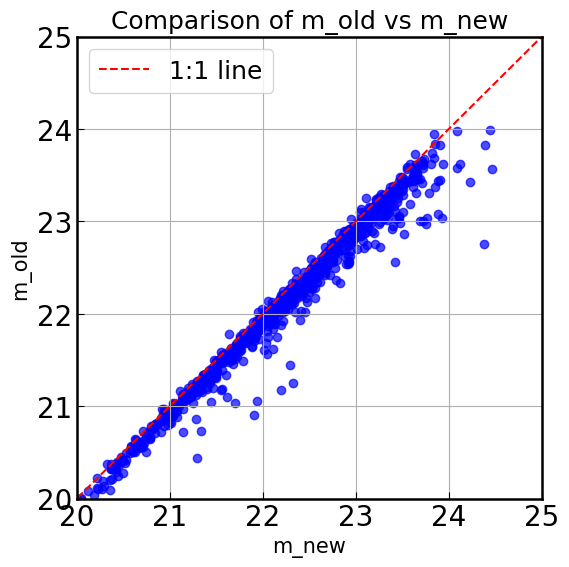

In [87]:
plt.figure(figsize=(6, 6))
plt.scatter(m_new, m_old, c='blue', alpha=0.7)
plt.plot([np.nanmin(m_new), np.nanmax(m_new)], [np.nanmin(m_new), np.nanmax(m_new)], 'r--', label='1:1 line')
plt.xlabel('m_new')
plt.ylabel('m_old')
plt.xlim(20, 25)
plt.ylim(20, 25)
plt.title('Comparison of m_old vs m_new')
plt.legend()
plt.grid(True)
plt.show()

In [88]:
np.max(f_host)

np.float64(-1.0)

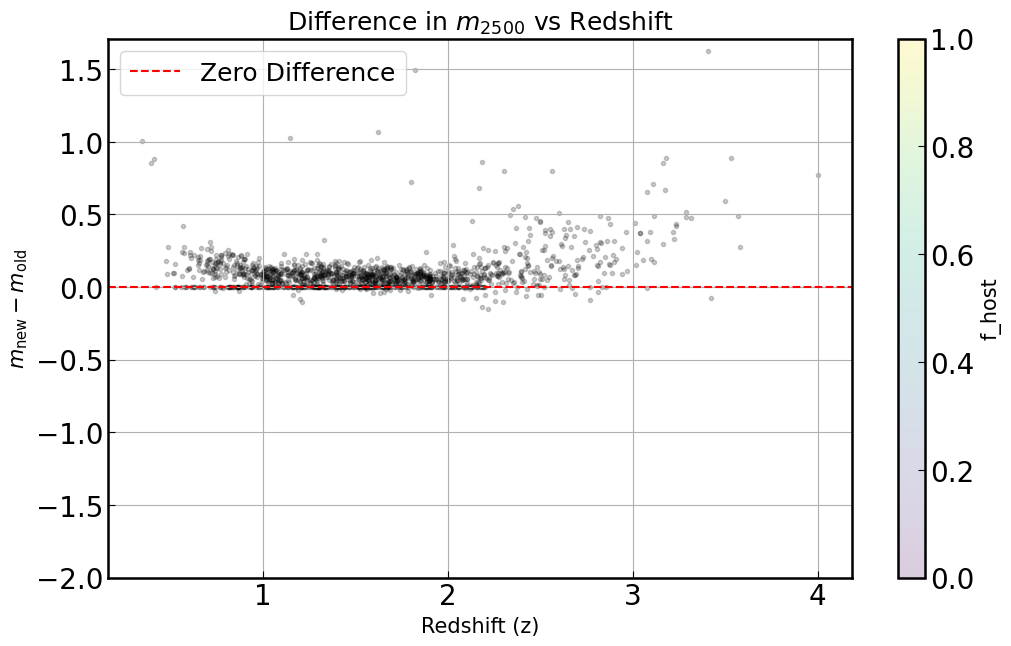

In [89]:
plt.figure(figsize=(12, 7))
f_host_clipped = np.clip(f_host[:ntest], 0, 1)
sc = plt.scatter(data_cat['Z_SYS'][:ntest], m_new - m_old, c=np.log(f_host_clipped[:ntest]), cmap='viridis', alpha=0.2, marker='.')
mask = f_host[:ntest]<0
sc = plt.scatter(data_cat['Z_SYS'][:ntest][mask], m_new[mask] - m_old[mask], c='k', cmap='viridis', alpha=0.2, marker='.')
plt.colorbar(sc, label='f_host')
plt.axhline(0, color='r', linestyle='--', label='Zero Difference')
plt.xlabel('Redshift (z)')
plt.ylabel(r'$m_\mathrm{new} - m_\mathrm{old}$')
plt.title(r'Difference in $m_{2500}$ vs Redshift')
plt.ylim(-2, )
plt.grid(True)
plt.legend()
plt.show()

In [67]:
len(f_host[f_host>0])

0

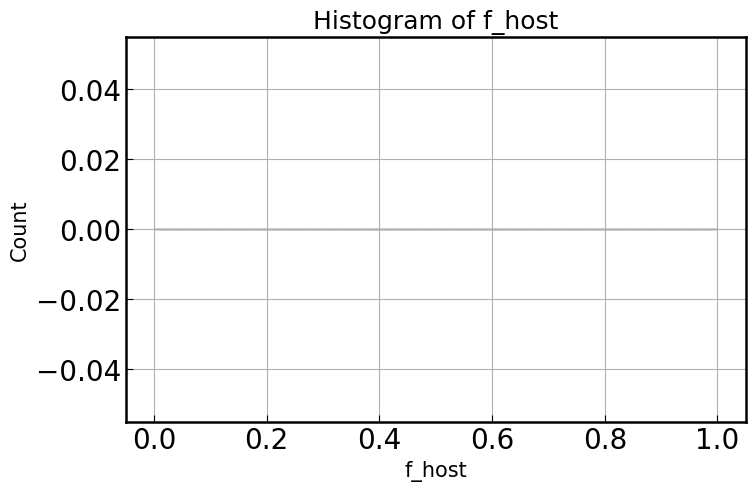

In [68]:
plt.figure(figsize=(8, 5))
plt.hist(f_host[f_host>0], bins=30, color='skyblue', edgecolor='k')
plt.xlabel('f_host')
plt.ylabel('Count')
plt.title('Histogram of f_host')
plt.grid(True)
plt.show()

In [69]:
# mu = m - M
# new m is larger at low-z, so mu is larger at low-z

In [70]:
len(agn_df)

1403

In [71]:
len(m_new)

226

In [72]:
data_cat_save

NameError: name 'data_cat_save' is not defined

In [90]:
data_cat['apparent_mag_2500_colin'] = m_new
data_cat['f_host_4200'] = f_host
data_cat_save = data_cat['SDSS_NAME', 'RA', 'DEC', 'apparent_mag_2500_colin', 'f_host_4200']
data_cat_save.write('data/sdss_qso_mag_2500_colin.csv', format='csv', overwrite=True)

In [ ]:
# calculate m_2500 from the continuum luminosity at 2500A using my fits
# compare with isaques values using his interpolation function